In [3152]:
gen_report = False

In [3153]:
import os
import json
import pandas as pd

root = "experiments"

records = []

for dirpath, dirnames, filenames in os.walk(root):
    if "report.json" in filenames:
        report_path = os.path.join(dirpath, "report.json")

        with open(report_path, "r") as f:
            data = json.load(f)

        record = {}

        record["VQEL"] = data.get("VQEL")

        # metrics
        for k, v in data.get("metrics", {}).items():
            record[k] = v

        # config
        for k, v in data.get("config", {}).items():
            if 'dir' in k.lower() or 'split' in k.lower():
                continue
            record[k] = v

        record["path"] = dirpath.replace('experiments/', '').replace('/results', '')
        records.append(record)

df = pd.DataFrame(records)

df["reset_unfrozen_params"] = df["reset_unfrozen_params"].map({True: "yes", False: "no"})
df["freeze_codebook"] = df["freeze_codebook"].map({True: "yes", False: "no"})
df["freeze_object_encoder"] = df["freeze_object_encoder"].map({True: "yes", False: "no"})

df.loc[df["num_iterations"] == 0, "learning_rate_tt"] = "-"
df.loc[df["agent_a_training_mode"] == 'frozen', "learning_rate_phase2_a"] = "-"
df.loc[df["best_of_n"].isna(), "best_of_n"] = 1
df.loc[df["dataset_tt"].isna(), "dataset_tt"] = "one_shape"
df.loc[df["sampling_temperature_tt"].isna(), "sampling_temperature_tt"] = df["sampling_temperature"]
df.loc[df["gumbel"].isna(), "gumbel"] = False

df.loc[(df["num_iterations"] == 0) | (df["best_of_n"] == 1), "test_time_mode"] = "-"

df.rename(columns={"test_time_training_accuracy": "test_time_mutual_accuracy"}, inplace=True)
df.rename(columns={"test_time_self_play_accuracy": "test_time_self_accuracy"}, inplace=True)

df["test_time_mode"] = df["test_time_mode"].replace("adaptation", "sample_adaptation")
df["dataset"] = df["dataset"].replace("shape", "shape1")
df["dataset_tt"] = df["dataset_tt"].replace("two_shape", "shape2")
df["dataset_tt"] = df["dataset_tt"].replace("shape_unique_double_attribute", "dual_attribute_shape")
# df["dataset_tt"] = df["dataset_tt"].replace("shape_unique_double_attribute", "single_attribute_shape")

df.loc[df["baseline"].isna(), "baseline"] = False

df.loc[df["baseline"], "test_time_mode"] = "-"


df = df.where(pd.notna(df), "None")
pd.options.display.float_format = '{:.10g}'.format
df = df.map(lambda x: f"{x:.0e}" if isinstance(x, (int, float)) and x != 0 and (abs(x) < 0.01 or abs(x) == 0.1 or abs(x) == 0.01) else x)
print("Total reports loaded:", len(df))

pd.set_option('display.max_rows', None)

Total reports loaded: 3088


/tmp/ipykernel_5433/1992355306.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[df["num_iterations"] == 0, "learning_rate_tt"] = "-"
/tmp/ipykernel_5433/1992355306.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[df["agent_a_training_mode"] == 'frozen', "learning_rate_phase2_a"] = "-"


In [3154]:
def filter_df(filters, df=df, sort_by=["message_length", "message_length_tt", "learning_rate_tt", "num_iterations"]):

    idx = pd.Series(True, index=df.index)

    for key, values in filters.items():
        mask = pd.Series(False, index=df.index)
        if not isinstance(values, (list, tuple, set)):
            values = [values]
        for value in values:
            if value == "!None":
                mask |= (df[key] != "None")
            else:
                mask |= (df[key] == value)
        idx &= mask 

    return df[idx].sort_values(by=sort_by).reset_index(drop=True)

    

In [3155]:
import base64

def to_html(df):    

    # ---- highlight rule ----
    # if 'mutual_play_accuracy' in df:
    #     max_col = 'mutual_play_accuracy'
    # else:
    #     max_col = 'test_accuracy'
    # max_val = pd.to_numeric(df[max_col]).max()

    # def highlight_max_row(row):
    #     if  pd.to_numeric(row[max_col]) == max_val:
    #         return ['font-weight: bold; background-color: #ffff99'] * len(row)
    #     else:
    #         return [''] * len(row)

    # ---- style ----
    styled = (
        df.style
            # .apply(highlight_max_row, axis=1)  # <<< APPLY HIGHLIGHT HERE
            .hide(axis="index")
            .format(
                lambda x: (
                    f"{int(x)}"                      # 20.0 -> 20
                    if isinstance(x, float) and x.is_integer()
                    else f"{x:.0e}"                  # small numbers -> scientific
                    if isinstance(x, (int, float)) and x != 0 and abs(x) < 0.01
                    else x
                )
            )
            .set_table_styles([
                {"selector": "td", "props": [("border-right", "1px solid black")]},
                {"selector": "th", "props": [
                    ("border-right", "1px solid black"),
                    ("color", "darkblue"),
                    ("font-weight", "bold"),
                    ("padding-left", "8px"),
                    ("padding-right", "8px")
                ]},
            ])
            .set_properties(**{"text-align": "center"})
    )

    html_table = styled.to_html(index=False)

    if gen_report:
        with open("results.html", "a") as f:
            f.write(html_table)

        
def add_heading(num=1, title=""):
    """Add a professional-colored heading to results.html"""
    colors = ["#0b3d91",  # dark blue
              "#800000",  # maroon
              "#205522",  # dark green
              "#111011",  # indigo
              "#444444"]  # dark gray
    color = colors[(num-1) % len(colors)]  # cycle through colors
    
    if gen_report:
        with open("results.html", "a") as f:
            f.write(f'<h{num} style="color:{color}; font-family:Arial, sans-serif;">{title}</h{num}>\n')
        
def clear():
    if gen_report:
        with open("results.html", "w") as f:
            f.write("")

def line():
    if gen_report:
        with open("results.html", "a") as f:
            f.write('<hr style="border:1px solid #444; margin:10px 0;">\n')
        
        
def write(text):
    html_text = text.replace("\n", "<br>\n")
    
    if gen_report:
        with open("results.html", "a") as f:
            f.write(f"{html_text}\n")


def add_plot(path="plot.png"):
    """Embed an image file directly into results.html using base64."""
    with open(path, "rb") as img:
        encoded = base64.b64encode(img.read()).decode("utf-8")

    html_img = (
        '<img src="data:image/png;base64,' +
        encoded +
        '" style="max-width:650px; height:auto;"><br>\n'
    )

    if gen_report:
        with open("results.html", "a") as f:
            f.write(html_img)
        
    if os.path.exists(path):
        os.remove(path)

In [3156]:
import os
import shutil

def remove_expr(res_df):
    for path in res_df["path"]:
        full_path = os.path.join("experiments", path)

        if not os.path.isdir(full_path):
            print(f"[SKIP] Not found: {full_path}")
            continue

        answer = input(f"⚠️ Delete expr '{path}' ? (y/n): ").strip().lower()

        if answer == "y":
            shutil.rmtree(full_path)
            print(f"✅ Deleted: {path}")
        else:
            print(f"❌ Skipped: {path}")

In [3157]:
from itertools import product
import pandas as pd


def extract_maxes(df, cols=["message_length", "message_length_tt", "seed"], max_col="test_time_mutual_accuracy"):
    values = []
    for col in cols:
        value = set(df[col])
        values.append(value)

    combinations = [list(x) for x in product(*values)]

    maxes = []
    for comb in combinations:
        section = filter_df({col: value for col, value in zip(cols, comb)}, df)
        if not section.empty:
            max_row = section.loc[pd.to_numeric(section[max_col]).idxmax()]
            maxes.append(max_row.to_frame().T)

    final_df = pd.concat(maxes, ignore_index=True)
    return final_df.sort_values(by=cols)


def mean_and_std(df, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode"], metrics=["test_time_self_accuracy", "test_time_mutual_accuracy"]):
    rows = []

    for i in range(0, len(df), 3):
        chunk = df.iloc[i:i+3]
        
        rows.append(
            {col: chunk[col].iloc[0] for col in config_cols} | 
            {metric: f"{pd.to_numeric(chunk[metric]).mean() * 100:.1f} ± {pd.to_numeric(chunk[metric]).std() * 100:.1f}" for metric in metrics}
        )

    out = pd.DataFrame(rows)
    return out.sort_values(by=config_cols)
    

In [3158]:
import matplotlib.pyplot as plt

METHOD_COLORS = {
    "GS-ST": "#8c2d04",
    "REINFORCE": "#1f77b4",
    "VQEL": "#ff7f0e",
    "VQEL + TTA (Batch)": "#2ca02c",
    "VQEL + TTA (Dataset)": "#9467bd",
    "Scaling": "#7f7f7f" ,
}


def plot(
    dfs,
    labels=("GS-ST", "REINFORCE", "VQEL", "VQEL + TTA (Batch)", "VQEL + TTA (Dataset)", "Scaling"),
    name="name",
    xcol="message_length_tt",
    xlabel="Message Length",
    ):
    fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

    all_x = []

    for df, label in zip(dfs, labels):
        if label not in METHOD_COLORS:
            raise ValueError(f"No color defined for label: {label}")

        color = METHOD_COLORS[label]

        df = df.copy()

        # Split "mean ± std"
        df[["mean_acc", "std_acc"]] = (
            df["test_time_mutual_accuracy"]
            .str.split("±", expand=True)
            .astype(float)
        )

        df = df.sort_values(xcol)

        x = df[xcol]
        y = df["mean_acc"]
        err = df["std_acc"]

        all_x.extend(x.tolist())

        ax.plot(
            x,
            y,
            marker="o",
            linewidth=2,
            color=color,
            label=label,
        )

        ax.fill_between(
            x,
            y - err,
            y + err,
            color=color,
            alpha=0.2,
            linewidth=0,
        )

    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel("Accuracy under Distribution Shift (\%)", fontsize=12)

    ax.set_xticks(sorted(set(all_x)))
    ax.tick_params(axis="both", labelsize=10)

    ax.legend(frameon=False)
    ax.grid(alpha=0.3)
    fig.tight_layout()

    plt.savefig(
        f"assets/{name}.pdf",
        format="pdf",
        bbox_inches="tight",
    )

    plt.show()
    

In [3159]:
# def plot(dfs, labels=("Baseline", "VQEL", "VQEL + TTA (Batch)", "scaling", "VQEL + TTA (Dataset)", "VQEL + TTA (Sample)"), name="name"):
#     fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

#     all_x = []

#     for df, label in zip(dfs, labels):
#         df = df.copy()

#         # Split "mean ± std"
#         df[["mean_acc", "std_acc"]] = (
#             df["test_time_mutual_accuracy"]
#             .str.split("±", expand=True)
#             .astype(float)
#         )

#         df = df.sort_values("message_length_tt")

#         x = df["message_length_tt"]
#         y = df["mean_acc"]
#         err = df["std_acc"]

#         all_x.extend(x.tolist())

#         ax.plot(x, y, marker="o", linewidth=2, label=label)
#         # ax.plot(x, y, linewidth=2, label=label)

#         ax.fill_between(x, y - err, y + err, alpha=0.2)

#     ax.set_xlabel("Message Length", fontsize=12)
#     ax.set_ylabel("Accuracy under Distribution Shift (\%)", fontsize=12)

#     ax.set_xticks(sorted(set(all_x)))
#     ax.tick_params(axis="both", labelsize=10)

#     ax.legend(frameon=False)
#     ax.grid(alpha=0.3)
#     fig.tight_layout()
    
#     plt.savefig(
#         f"assets/{name}.pdf",
#         format="pdf",
#         bbox_inches="tight"
#     )

#     plt.show()

In [3160]:
clear()

---

In [3161]:
gumbel_cols = [
    "seed",
    "baseline",
    "dataset",
    "sim",
    "message_length",
    "learning_rate_phase2_a", 
    "learning_rate_phase2_b",
    "tau_0",
    "mutual_play_accuracy",
    "sampling_temperature",
    "test_time_mode",
    "path",
]

backbone_cols = [
    "seed",
    "baseline",
    "dataset",
    "sim",
    "message_length",
    "learning_rate_phase1", 
    "learning_rate_phase2_a", 
    "learning_rate_phase2_b",
    "test_time_mode",
    "self_play_accuracy_a",
    "mutual_play_accuracy",
    "path",
]

backbone_cols_report = [
    "seed",
    "message_length",
    "agent_a_training_mode",
    "self_play_accuracy_a",
    "mutual_play_accuracy",
]

baseline_cols = [
    "seed",
    "baseline",
    "dataset",
    "sim",
    "message_length",
    "message_length_tt",
    "dataset_tt",
    "test_time_mode",
    "test_time_self_accuracy",
    "test_time_mutual_accuracy",
    "path",
]

baseline_cols_report = [
    "seed",
    "message_length",
    "message_length_tt",
    "dataset_tt",
    "test_time_mode",
    "test_time_self_accuracy",
    "test_time_mutual_accuracy",
]

scaling_cols = [
    "seed",
    "baseline",
    "dataset",
    "sim",
    "message_length",
    "message_length_tt",
    "dataset_tt",
    "test_time_mode",
    "sampling_temperature_tt",
    "best_of_n",
    "test_time_self_accuracy",
    "test_time_mutual_accuracy",
    "path",
]

scaling_cols_report = [
    "seed",
    "message_length",
    "message_length_tt",
    "dataset_tt",
    "test_time_mode",
    "sampling_temperature_tt",
    "best_of_n",
    "test_time_self_accuracy",
    "test_time_mutual_accuracy",
]

adapt_cols = [
    "seed",
    "baseline",
    "dataset",
    "sim",
    "message_length",
    "message_length_tt",
    "dataset_tt",
    "test_time_mode",
    "learning_rate_tt",
    "num_iterations",
    "test_time_self_accuracy",
    "test_time_mutual_accuracy",
    "path",
]

adapt_cols_report = [
    "seed",
    "message_length",
    "message_length_tt",
    "dataset_tt",
    "test_time_mode",
    "learning_rate_tt",
    "num_iterations",
    "test_time_self_accuracy",
    "test_time_mutual_accuracy",
]

In [3162]:
write(
"""
- <b>Shape1</b>: Contains only one shape.

- <b>Shape2</b>: Contains exactly two shapes.

- <b>Shape12</b>: Contains one or two shapes.

- <b>MNIST1</b>: Contains one digit on either the left or right side of the image (the other side is empty).

- <b>MNIST2</b>: Contains two digits.

- <b>ImageNet_same_class</b>: Distractors and targets belong to the same class.

- <b>Single Attribute Shape</b>: Candidates in a batch have two attributes; the value of one attribute is different for all images,
while there is no restriction on the value of the other attribute—it may be the same for some images and different for others.

- <b>Dual-attribute shape</b>: Candidates in a batch have two attributes, and all candidates can be distinguished from one another 
if and only if the values of both attributes are described.
"""
)

# Shape

## Gumbel - ID

In [3163]:
res = filter_df({
    "dataset": "shape1",
    "sim": "cosine",
    "dialogued_checkpoint": "None",
    "baseline": True,
    "gumbel": True
}, sort_by=["seed"])

# res[gumbel_cols]

In [3164]:
final = extract_maxes(res, max_col="mutual_play_accuracy")
final[gumbel_cols]

,seed,baseline,dataset,sim,message_length,learning_rate_phase2_a,learning_rate_phase2_b,tau_0,mutual_play_accuracy,sampling_temperature,test_time_mode,path
0,1,True,shape1,cosine,"[3, 4]",-,1e-05,1e-01,0.834,1e-05,-,20260213_1014_bs32_vocab10_repr1024_msg_len4_l...
1,2,True,shape1,cosine,"[3, 4]",-,1e-05,0.2,0.842,1e-05,-,20260217_0243_bs32_vocab10_repr1024_msg_len4_l...
2,3,True,shape1,cosine,"[3, 4]",-,1e-05,0.3,0.849,1e-05,-,20260217_0809_bs32_vocab10_repr1024_msg_len4_l...


In [3165]:
final.loc[2, 'path']

'20260217_0809_bs32_vocab10_repr1024_msg_len4_lr1_1e-05_lr2a_1e-05_lr2b_1e-05_decay0.99_modefrozen_temp1e-05_ent0_cand100_contr0.01_seed3'

In [3166]:
mean = mean_and_std(final, config_cols = ["dataset", "message_length"], metrics = ["mutual_play_accuracy"])
to_html(mean)
mean

,dataset,message_length,mutual_play_accuracy
0,shape1,"[3, 4]",84.2 ± 0.8


## Gumbel - OOD

In [3167]:
res = filter_df({
    "dataset": "shape1",
    "sim": "cosine",
    "dialogued_checkpoint": "!None",
    "baseline": True,
    "gumbel": True,
}, sort_by=["message_length_tt", "seed"])

# res[baseline_cols]

In [3168]:
gumbel = mean_and_std(res)
gumbel

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_self_accuracy,test_time_mutual_accuracy
0,shape1,"[3, 4]",4,shape2,-,0.0 ± 0.0,38.8 ± 0.7
1,shape1,"[3, 4]",5,shape2,-,0.0 ± 0.0,39.5 ± 0.4
2,shape1,"[3, 4]",6,shape2,-,0.0 ± 0.0,39.0 ± 1.3
3,shape1,"[3, 4]",7,shape2,-,0.0 ± 0.0,39.0 ± 1.2
4,shape1,"[3, 4]",8,shape2,-,0.0 ± 0.0,38.5 ± 1.7
5,shape1,"[3, 4]",9,shape2,-,0.0 ± 0.0,36.8 ± 2.3
6,shape1,"[3, 4]",10,shape2,-,0.0 ± 0.0,34.4 ± 2.5
7,shape1,"[3, 4]",11,shape2,-,0.0 ± 0.0,31.9 ± 2.2
8,shape1,"[3, 4]",12,shape2,-,0.0 ± 0.0,29.8 ± 2.8
9,shape1,"[3, 4]",13,shape2,-,0.0 ± 0.0,27.0 ± 3.0


## REINFORCE - ID

In [3169]:
add_heading(3, "Baseline")

res = filter_df({
    "dataset": "shape1",
    "sim": "cosine",
    "dialogued_checkpoint": "None",
    "baseline": True,
    "gumbel": False
}, sort_by=["seed"])

res[backbone_cols]

,seed,baseline,dataset,sim,message_length,learning_rate_phase1,learning_rate_phase2_a,learning_rate_phase2_b,test_time_mode,self_play_accuracy_a,mutual_play_accuracy,path
0,1,True,shape1,cosine,"[3, 4]",1e-04,-,1e-04,-,0,0.863,20251230_1445_bs32_vocab10_repr1024_msg_len4_l...
1,2,True,shape1,cosine,"[3, 4]",1e-04,-,1e-04,-,0,0.865,20251230_1503_bs32_vocab10_repr1024_msg_len4_l...
2,3,True,shape1,cosine,"[3, 4]",1e-04,-,1e-04,-,0,0.867,20251230_1518_bs32_vocab10_repr1024_msg_len4_l...


In [3170]:
mean = mean_and_std(res, config_cols = ["dataset", "message_length"], metrics = ["mutual_play_accuracy"])
to_html(mean)
mean

,dataset,message_length,mutual_play_accuracy
0,shape1,"[3, 4]",86.5 ± 0.2


## REINFORCE - OOD

In [3171]:
res = filter_df({
    "dataset": "shape1",
    "sim": "cosine",
    "dialogued_checkpoint": "!None",
    "baseline": True,
    "gumbel": False
}, sort_by=["message_length_tt", "seed"])
# res[baseline_cols]

In [3172]:
REINFORCE = mean_and_std(res)
# REINFORCE

## VQEL - ID

In [3173]:
add_heading(2, "Shape1")
add_heading(3, "Base Model")

res = filter_df({
    "dataset": "shape1",
    "sim": "cosine",
    "baseline": False,
    "message_length": "[3, 4]",
    "test_time_mode": "-",
    "dialogued_checkpoint": "None",
}, sort_by=["message_length"])
res = extract_maxes(res, max_col="mutual_play_accuracy")

res[backbone_cols]

,seed,baseline,dataset,sim,message_length,learning_rate_phase1,learning_rate_phase2_a,learning_rate_phase2_b,test_time_mode,self_play_accuracy_a,mutual_play_accuracy,path
2,1,False,shape1,cosine,"[3, 4]",1e-03,-,1e-04,-,0.841,0.889,20251220_0615_bs32_vocab10_repr1024_lr1_0.001_...
0,2,False,shape1,cosine,"[3, 4]",1e-03,-,1e-03,-,0.837,0.888,20251228_1437_bs32_vocab10_repr1024_msg_len10_...
1,3,False,shape1,cosine,"[3, 4]",1e-03,-,1e-04,-,0.846,0.885,20251228_2016_bs32_vocab10_repr1024_msg_len10_...


In [3174]:
mean = mean_and_std(res, config_cols = ["dataset", "message_length"], metrics = ["self_play_accuracy_a", "mutual_play_accuracy"])
to_html(mean)
mean

,dataset,message_length,self_play_accuracy_a,mutual_play_accuracy
0,shape1,"[3, 4]",84.1 ± 0.5,88.7 ± 0.2


## VQEL - OOD

In [3175]:
add_heading(3, "Baseline")

res = filter_df({
    "dataset": "shape1",
    "sim": "cosine",
    "dataset_tt": "shape2",
    "baseline": False,
    "message_length": "[3, 4]",
    "test_time_mode": "-"
}, sort_by=["message_length_tt", "seed"])

to_html(res[baseline_cols_report])

# res[baseline_cols]

In [3176]:
VQ_NoTT = mean_and_std(res)
# VQ_NoTT

## Scaling

In [3177]:
add_heading(3, "Scaling")

res = filter_df({
    "dataset": "shape1",
    "sim": "cosine",
    "VQEL": True,
    "message_length": "[3, 4]",
    "test_time_mode": "scaling"
}, sort_by=["message_length", "message_length_tt", "seed", "sampling_temperature_tt", "best_of_n"])

to_html(res[scaling_cols_report])

# res[scaling_cols]

In [3178]:
final = extract_maxes(res)
# final[scaling_cols]

In [3179]:
scaling = mean_and_std(final)
# scaling

## Batch Adaptation

In [3180]:
add_heading(3, "Adaptation")

res = filter_df({
    "dataset": "shape1",
    "sim": "cosine",
    "VQEL": True,
    "message_length": "[3, 4]",
    "test_time_mode": ["batch_adaptation"],
}, sort_by=["message_length_tt","seed", "learning_rate_tt"])

to_html(res[adapt_cols_report])

# res[adapt_cols]

In [3181]:
final = extract_maxes(res)
# final[adapt_cols]

In [3182]:
batch_adapt = mean_and_std(final)
# batch_adapt

## Dataset Adaptation

In [3183]:
res = filter_df({
    "dataset": "shape1",
    "sim": "cosine",
    "VQEL": True,
    "message_length": "[3, 4]",
    "test_time_mode": ["dataset_adaptation"],
}, sort_by=["message_length_tt","seed", "learning_rate_tt"])

# res[adapt_cols]

In [3184]:
final = extract_maxes(res)
# final[adapt_cols]

In [3185]:
dataset_adapt = mean_and_std(final)
# dataset_adapt

## Plot

In [3186]:
# plot([gumbel, REINFORCE, VQ_NoTT, batch_adapt, dataset_adapt], name="shape")

In [3187]:
# plot([gumbel, REINFORCE, VQ_NoTT, batch_adapt, scaling], labels=("GS-ST", "REINFORCE", "VQEL", "VQEL + TTA (Batch)", "Scaling"),name="shape-scaling")

# MNIST

## Gumbel - ID

In [3188]:
add_heading(3, "Baseline")

res = filter_df({
    "dataset": "mnist1",
    "baseline": True,
    "dialogued_checkpoint": "None",
    "gumbel": True,
}, sort_by=["seed"])

# res[gumbel_cols]

In [3189]:
final = extract_maxes(res, max_col="mutual_play_accuracy")
final[gumbel_cols]

,seed,baseline,dataset,sim,message_length,learning_rate_phase2_a,learning_rate_phase2_b,tau_0,mutual_play_accuracy,sampling_temperature,test_time_mode,path
0,1,True,mnist1,cosine,"[3, 4]",-,1e-05,1e-01,0.808,1e-05,-,20260212_1441_bs32_vocab10_repr192_msg_len4_lr...
1,2,True,mnist1,cosine,"[3, 4]",-,1e-05,1e-01,0.803,1e-05,-,20260216_2326_bs32_vocab10_repr192_msg_len4_lr...
2,3,True,mnist1,cosine,"[3, 4]",-,1e-05,0.3,0.794,1e-05,-,20260217_1444_bs32_vocab10_repr192_msg_len4_lr...


In [3190]:
mean = mean_and_std(final, config_cols = ["dataset", "message_length"], metrics = ["mutual_play_accuracy"])
to_html(mean)
mean

,dataset,message_length,mutual_play_accuracy
0,mnist1,"[3, 4]",80.2 ± 0.7


## Gumbel - OOD

In [3191]:
res = filter_df({
    "dataset": "mnist1",
    "baseline": True,
    "dialogued_checkpoint": "!None",
    "gumbel": True,
}, sort_by=["message_length_tt", "seed"])

# res[baseline_cols]

In [3192]:
gumbel = mean_and_std(res)
# gumbel

## REINFORCE - ID

In [3193]:
add_heading(3, "Baseline")

res = filter_df({
    "dataset": "mnist1",
    "baseline": True,
    "dialogued_checkpoint": "None",
    "gumbel": False,
}, sort_by=["seed"])

res[backbone_cols]

,seed,baseline,dataset,sim,message_length,learning_rate_phase1,learning_rate_phase2_a,learning_rate_phase2_b,test_time_mode,self_play_accuracy_a,mutual_play_accuracy,path
0,1,True,mnist1,cosine,"[3, 4]",1e-04,-,1e-04,-,0,0.925,20251230_1620_bs32_vocab10_repr192_msg_len4_lr...
1,2,True,mnist1,cosine,"[3, 4]",1e-04,-,1e-04,-,0,0.858,20251230_1705_bs32_vocab10_repr192_msg_len4_lr...
2,3,True,mnist1,cosine,"[3, 4]",1e-04,-,1e-04,-,0,0.882,20251230_1750_bs32_vocab10_repr192_msg_len4_lr...


In [3194]:
mean_and_std(res)

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_self_accuracy,test_time_mutual_accuracy
0,mnist1,"[3, 4]",4,mnist1,-,0.0 ± 0.0,86.9 ± 2.3


## REINFORCE - OOD

In [3195]:
res = filter_df({
    "dataset": "mnist1",
    "baseline": True,
    "dialogued_checkpoint": "!None",
    "gumbel": False,
}, sort_by=["message_length_tt", "seed"])

# res[baseline_cols]

In [3196]:
REINFORCE = mean_and_std(res)
# baseline

## VQEL - ID

In [3197]:
add_heading(2, "MNIST")
add_heading(3, 'Base Model')
res = filter_df({
    "dataset": "mnist1",
    "sim": "cosine",
    "baseline": False,
    "test_time_mode": "-",
    "dataset_tt": "mnist1",
    "message_length": "[3, 4]",
}, sort_by=["message_length", "message_length_tt"])


res[backbone_cols]

,seed,baseline,dataset,sim,message_length,learning_rate_phase1,learning_rate_phase2_a,learning_rate_phase2_b,test_time_mode,self_play_accuracy_a,mutual_play_accuracy,path
0,1,False,mnist1,cosine,"[3, 4]",1e-04,-,1e-04,-,0.788,0.895,20251223_1750_bs32_vocab10_repr192_lr1_0.0001_...
1,2,False,mnist1,cosine,"[3, 4]",1e-04,-,1e-04,-,0.787,0.891,20251228_1548_bs32_vocab10_repr192_msg_len10_l...
2,3,False,mnist1,cosine,"[3, 4]",1e-04,-,1e-04,-,0.799,0.918,20251228_1637_bs32_vocab10_repr192_msg_len10_l...


In [3198]:
mean = mean_and_std(res, config_cols = ["dataset", "message_length"], metrics = ["self_play_accuracy_a", "mutual_play_accuracy"])
mean

,dataset,message_length,self_play_accuracy_a,mutual_play_accuracy
0,mnist1,"[3, 4]",79.1 ± 0.7,90.1 ± 1.5


## VQEL - OOD

In [3199]:
add_heading(3, "Baseline")

res = filter_df({
    "dataset": "mnist1",
    "sim": "cosine",
    "dataset_tt": "mnist2",
    "baseline": False,
    "test_time_mode": "-"
}, sort_by=["message_length", "message_length_tt", "seed"])

# res[baseline_cols]

In [3200]:
VQ_NoTT = mean_and_std(res)
# VQ_NoTT

## Scaling

In [3201]:
add_heading(3, "Scaling")
res = filter_df({
    "dataset": "mnist1",
    "sim": "cosine",
    "baseline": False,
    "test_time_mode": "scaling",
    "sampling_temperature_tt": "1e-02"
}, sort_by=["message_length", "message_length_tt", "sampling_temperature_tt", "best_of_n"])

# res[scaling_cols]

In [3202]:
final = extract_maxes(res)
# final[scaling_cols]

In [3203]:
scaling = mean_and_std(final)
# scaling

## Batch Adaptation

In [3204]:
add_heading(3, "Adaptation")

res = filter_df({
    "dataset": "mnist1",
    "VQEL": True,
    "test_time_mode": ["batch_adaptation"],
}, sort_by=["message_length_tt", "seed", "learning_rate_tt", "num_iterations"])

# res[adapt_cols]

In [3205]:
final = extract_maxes(res)
# final[adapt_cols]

In [3206]:
batch_adapt = mean_and_std(final)
# batch_adapt

## Dataset Adaptation

In [3207]:
add_heading(3, "Adaptation")

res = filter_df({
    "dataset": "mnist1",
    "VQEL": True,
    "test_time_mode": ["dataset_adaptation"],
    # "num_iterations": [5, 10],
}, sort_by=["message_length_tt", "seed", "learning_rate_tt", "num_iterations"])

# res[adapt_cols]

In [3208]:
final = extract_maxes(res)
# final[adapt_cols]

In [3209]:
dataset_adapt = mean_and_std(final)
# dataset_adapt

## Plot

In [3210]:
# plot([gumbel, REINFORCE, VQ_NoTT, batch_adapt, dataset_adapt], name="mnist")

In [3211]:
# plot([gumbel, REINFORCE, VQ_NoTT, batch_adapt, scaling], labels=("GS-ST", "REINFORCE", "VQEL", "VQEL + TTA (Batch)", "Scaling"),name="mnist-scaling")

# Objects

In [3212]:
vq_cols = [
    "seed",
    "baseline",
    "dataset",
    "sim",
    "vocab_size",
    "message_length",
    # "learning_rate_phase1", 
    # "learning_rate_phase2_a", 
    # "learning_rate_phase2_b",
    "test_time_mode",
    "self_play_accuracy_a",
    "mutual_play_accuracy",
    "test_time_self_accuracy",
    "test_time_mutual_accuracy",
    "path",
]

In [3213]:
res = filter_df({
    "dataset": "objects",
    "baseline": False,
    # "message_length": "[2, 3, 4]",
    "dialogued_checkpoint": "None",
}, sort_by=["message_length", "vocab_size"])


res[vq_cols]

,seed,baseline,dataset,sim,vocab_size,message_length,test_time_mode,self_play_accuracy_a,mutual_play_accuracy,test_time_self_accuracy,test_time_mutual_accuracy,path
0,1,False,objects,cosine,10,"[1, 2]",-,0.375,0.125,0.062,0,20260216_0834_bs1_vocab10_repr32_msg_len4_lr1_...
1,1,False,objects,cosine,20,"[1, 2]",-,0.438,0.188,0.312,0.188,20260216_0840_bs1_vocab20_repr32_msg_len4_lr1_...
2,1,False,objects,cosine,30,"[1, 2]",-,0.375,0.188,0.25,0.188,20260216_0847_bs1_vocab30_repr32_msg_len4_lr1_...
3,1,False,objects,cosine,40,"[1, 2]",-,0.562,0.25,0.125,0,20260216_0853_bs1_vocab40_repr32_msg_len4_lr1_...
4,1,False,objects,cosine,50,"[1, 2]",-,0.5,0.312,0.375,0.188,20260216_0942_bs1_vocab50_repr32_msg_len4_lr1_...
5,1,False,objects,cosine,80,"[1, 2]",-,0.562,0.375,0.562,0.125,20260216_0947_bs1_vocab80_repr32_msg_len4_lr1_...
6,1,False,objects,cosine,100,"[1, 2]",-,0.625,0.312,0.438,0.125,20260216_0953_bs1_vocab100_repr32_msg_len4_lr1...
7,1,False,objects,cosine,10,[1],-,0.062,0.062,0,0,20260216_0409_bs1_vocab10_repr32_msg_len4_lr1_...
8,1,False,objects,cosine,20,[1],-,0.062,0.125,0,0,20260216_0414_bs1_vocab20_repr32_msg_len4_lr1_...
9,1,False,objects,cosine,30,[1],-,0.125,0.125,0,0,20260216_0419_bs1_vocab30_repr32_msg_len4_lr1_...


In [3214]:
res.loc[39, "path"]

'20260216_0033_bs1_vocab50_repr32_msg_len4_lr1_0.001_lr2a_0.001_lr2b_0.001_decay0.99_modefrozen_temp1e-05_ent0_cand1_contr0.01_seed1'

In [3215]:
res = filter_df({
    "dataset": "objects",
    "baseline": True,
    # "message_length": "[2, 3, 4]",
    "dialogued_checkpoint": "None",
}, sort_by=["message_length", "vocab_size"])


res[vq_cols]

,seed,baseline,dataset,sim,vocab_size,message_length,test_time_mode,self_play_accuracy_a,mutual_play_accuracy,test_time_self_accuracy,test_time_mutual_accuracy,path
0,1,True,objects,cosine,10,"[3, 4]",-,0,0,0,1e-01,20260218_0720_bs1_vocab10_repr32_msg_len4_lr1_...
1,1,True,objects,cosine,10,"[3, 4]",-,0,0,0,0,20260218_1212_bs1_vocab10_repr32_msg_len4_lr1_...
2,1,True,objects,cosine,10,"[3, 4]",-,0,0,0,0,20260218_0312_bs1_vocab10_repr32_msg_len4_lr1_...
3,1,True,objects,cosine,10,"[3, 4]",-,0,0.2,0,0,20260217_2307_bs1_vocab10_repr32_msg_len4_lr1_...
4,1,True,objects,cosine,10,"[3, 4]",-,0,1e-01,0,1e-01,20260218_1639_bs1_vocab10_repr16_msg_len4_lr1_...
5,1,True,objects,cosine,20,"[3, 4]",-,0,0,0,0,20260218_1250_bs1_vocab20_repr32_msg_len4_lr1_...
6,1,True,objects,cosine,20,"[3, 4]",-,0,0,0,0.2,20260217_2337_bs1_vocab20_repr32_msg_len4_lr1_...
7,1,True,objects,cosine,20,"[3, 4]",-,0,0,0,0,20260218_0344_bs1_vocab20_repr32_msg_len4_lr1_...
8,1,True,objects,cosine,20,"[3, 4]",-,0,0,0,0,20260218_1710_bs1_vocab20_repr16_msg_len4_lr1_...
9,1,True,objects,cosine,20,"[3, 4]",-,0,1e-01,0,0,20260218_0751_bs1_vocab20_repr32_msg_len4_lr1_...


# ImageNet

## Gumbel - ID

In [3216]:
add_heading(3, "Baseline")

res = filter_df({
    "dataset": "imagenet",
    "baseline": True,
    "message_length": "[2, 3, 4]",
    "dialogued_checkpoint": "None",
    "gumbel": True,
}, sort_by=["message_length", "seed"])

# res[gumbel_cols]

In [3217]:
final = extract_maxes(res, max_col="mutual_play_accuracy")
final[gumbel_cols]

,seed,baseline,dataset,sim,message_length,learning_rate_phase2_a,learning_rate_phase2_b,tau_0,mutual_play_accuracy,sampling_temperature,test_time_mode,path
0,1,True,imagenet,cosine,"[2, 3, 4]",-,1e-05,1e-01,0.726,1,-,20260214_1231_bs32_vocab10_repr2048_msg_len4_l...
1,2,True,imagenet,cosine,"[2, 3, 4]",-,1e-05,1e-01,0.736,1e-05,-,20260217_0025_bs32_vocab10_repr2048_msg_len4_l...
2,3,True,imagenet,cosine,"[2, 3, 4]",-,1e-05,1e-01,0.744,1e-05,-,20260217_0215_bs32_vocab10_repr2048_msg_len4_l...


In [3218]:
for i in range(3):
    print(final.loc[i, 'path'])

20260214_1231_bs32_vocab10_repr2048_msg_len4_lr1_1e-05_lr2a_1e-05_lr2b_1e-05_decay0.99_modefrozen_temp1_ent0_cand100_contr0.01_seed1
20260217_0025_bs32_vocab10_repr2048_msg_len4_lr1_1e-05_lr2a_1e-05_lr2b_1e-05_decay0.99_modefrozen_temp1e-05_ent0_cand100_contr0.01_seed2
20260217_0215_bs32_vocab10_repr2048_msg_len4_lr1_1e-05_lr2a_1e-05_lr2b_1e-05_decay0.99_modefrozen_temp1e-05_ent0_cand100_contr0.01_seed3


In [3219]:
mean = mean_and_std(final, config_cols = ["dataset", "message_length"], metrics = ["mutual_play_accuracy"])
to_html(mean)
mean

,dataset,message_length,mutual_play_accuracy
0,imagenet,"[2, 3, 4]",73.5 ± 0.9


## Gumbel - OOD

In [3220]:
res = filter_df({
    "dataset": "imagenet",
    "baseline": True,
    "dialogued_checkpoint": "!None",
    "gumbel": True,
}, sort_by=["message_length_tt", "seed"])

# res[baseline_cols]

In [3221]:
gumbel = mean_and_std(res)
# gumbel

## REINFORCE - ID

In [3222]:
add_heading(3, "Baseline")

res = filter_df({
    "dataset": "imagenet",
    "baseline": True,
    "message_length": "[2, 3, 4]",
    "dialogued_checkpoint": "None",
    "gumbel": False,
}, sort_by=["message_length", "seed"])

res[backbone_cols]

,seed,baseline,dataset,sim,message_length,learning_rate_phase1,learning_rate_phase2_a,learning_rate_phase2_b,test_time_mode,self_play_accuracy_a,mutual_play_accuracy,path
0,1,True,imagenet,cosine,"[2, 3, 4]",1e-05,-,1e-05,-,0,0.859,20251231_1826_bs32_vocab10_repr2048_msg_len4_l...
1,2,True,imagenet,cosine,"[2, 3, 4]",1e-05,-,1e-05,-,0,0.846,20251231_1934_bs32_vocab10_repr2048_msg_len4_l...
2,3,True,imagenet,cosine,"[2, 3, 4]",1e-05,-,1e-05,-,0,0.869,20251231_1958_bs32_vocab10_repr2048_msg_len4_l...


In [3223]:
mean_and_std(res)

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_self_accuracy,test_time_mutual_accuracy
0,imagenet,"[2, 3, 4]",4,imagenet,-,0.0 ± 0.0,85.8 ± 1.2


## REINFORCE - OOD

In [3224]:
res = filter_df({
    "dataset": "imagenet",
    "dataset_tt": "imagenet_same_class",
    "baseline": True,
    "message_length": "[2, 3, 4]",
    "dialogued_checkpoint": "!None",
    "gumbel": False,
}, sort_by=["message_length_tt", "seed"])
# res[baseline_cols]

In [3225]:
final = extract_maxes(res)

In [3226]:
REINFORCE = mean_and_std(final)
# baseline

## VQEL - ID

In [3227]:
add_heading(2, "ImageNet")
add_heading(3, "Base Model")

res = filter_df({
    "dataset": "imagenet",
    "sim": "cosine",
    "baseline": False,
    "test_time_mode": "-",
    "dataset_tt": "imagenet",
    # "message_length": "[2, 3, 4]"
}, sort_by=["vocab_size", "message_length","seed", "message_length_tt"])


# res[["vocab_size"] + backbone_cols]

In [3228]:
res.loc[2, 'path']

'20260104_2043_bs32_vocab6_repr2048_msg_len3_lr1_0.0001_lr2a_0.0001_lr2b_0.0001_decay0.99_modefrozen_temp1e-05_ent0_cand32_contr0.01_seed1'

In [3229]:
mean = mean_and_std(res, config_cols = ["dataset", "message_length"], metrics = ["self_play_accuracy_a", "mutual_play_accuracy"])
mean

,dataset,message_length,self_play_accuracy_a,mutual_play_accuracy
0,imagenet,"[1, 2, 3]",61.8 ± 5.6,65.5 ± 4.3
1,imagenet,"[1, 2, 3]",71.1 ± 15.0,73.8 ± 13.3
2,imagenet,"[2, 3, 4]",88.7 ± 0.7,89.7 ± 0.4
3,imagenet,"[3, 4]",88.9 ± 1.1,88.9 ± 0.1


## VQEL - OOD

In [3230]:
add_heading(3, "Baseline")
res = filter_df({
    "dataset": "imagenet",
    "dataset_tt": "imagenet_same_class",
    "baseline": False,
    "test_time_mode": "-",
    "message_length": "[2, 3, 4]"
}, sort_by=["message_length", "message_length_tt", "seed"])

# res[baseline_cols]

In [3231]:
VQ_NoTT = mean_and_std(res)
# VQ_NoTT

## Scaling

In [3232]:
add_heading(3, "Scaling")
res = filter_df({
    "dataset": "imagenet",
    "dataset_tt": "imagenet_same_class",
    "baseline": False,
    "test_time_mode": 'scaling'
}, sort_by=["message_length_tt", "sampling_temperature_tt", "best_of_n"])

# res[scaling_cols]

In [3233]:
final = extract_maxes(res)
# final[scaling_cols]

In [3234]:
scaling = mean_and_std(final)
# scaling

## Batch Adaptation

In [3235]:
add_heading(3, "Adaptation")
res = filter_df({
    "dataset": "imagenet",
    "dataset_tt": "imagenet_same_class",
    "baseline": False,
    "test_time_mode": ["batch_adaptation"],
    "message_length": "[2, 3, 4]",
}, sort_by=["test_time_mode", "message_length_tt", "seed", "learning_rate_tt", "num_iterations"])

# res[adapt_cols]

In [3236]:
final = extract_maxes(res)
# final[adapt_cols]

In [3237]:
batch_adapt = mean_and_std(final)
# batch_adapt

## Dataset Adaptation

In [3238]:
add_heading(3, "Adaptation")
res = filter_df({
    "dataset": "imagenet",
    "dataset_tt": "imagenet_same_class",
    "baseline": False,
    "test_time_mode": ["dataset_adaptation"],
    "message_length": "[2, 3, 4]",
    # "num_iterations": [5],
}, sort_by=["test_time_mode", "message_length_tt", "seed", "learning_rate_tt", "num_iterations"])

# res[adapt_cols]

In [3239]:
final = extract_maxes(res)
# final[adapt_cols]

In [3240]:
dataset_adapt = mean_and_std(final)
# dataset_adapt

## Plot

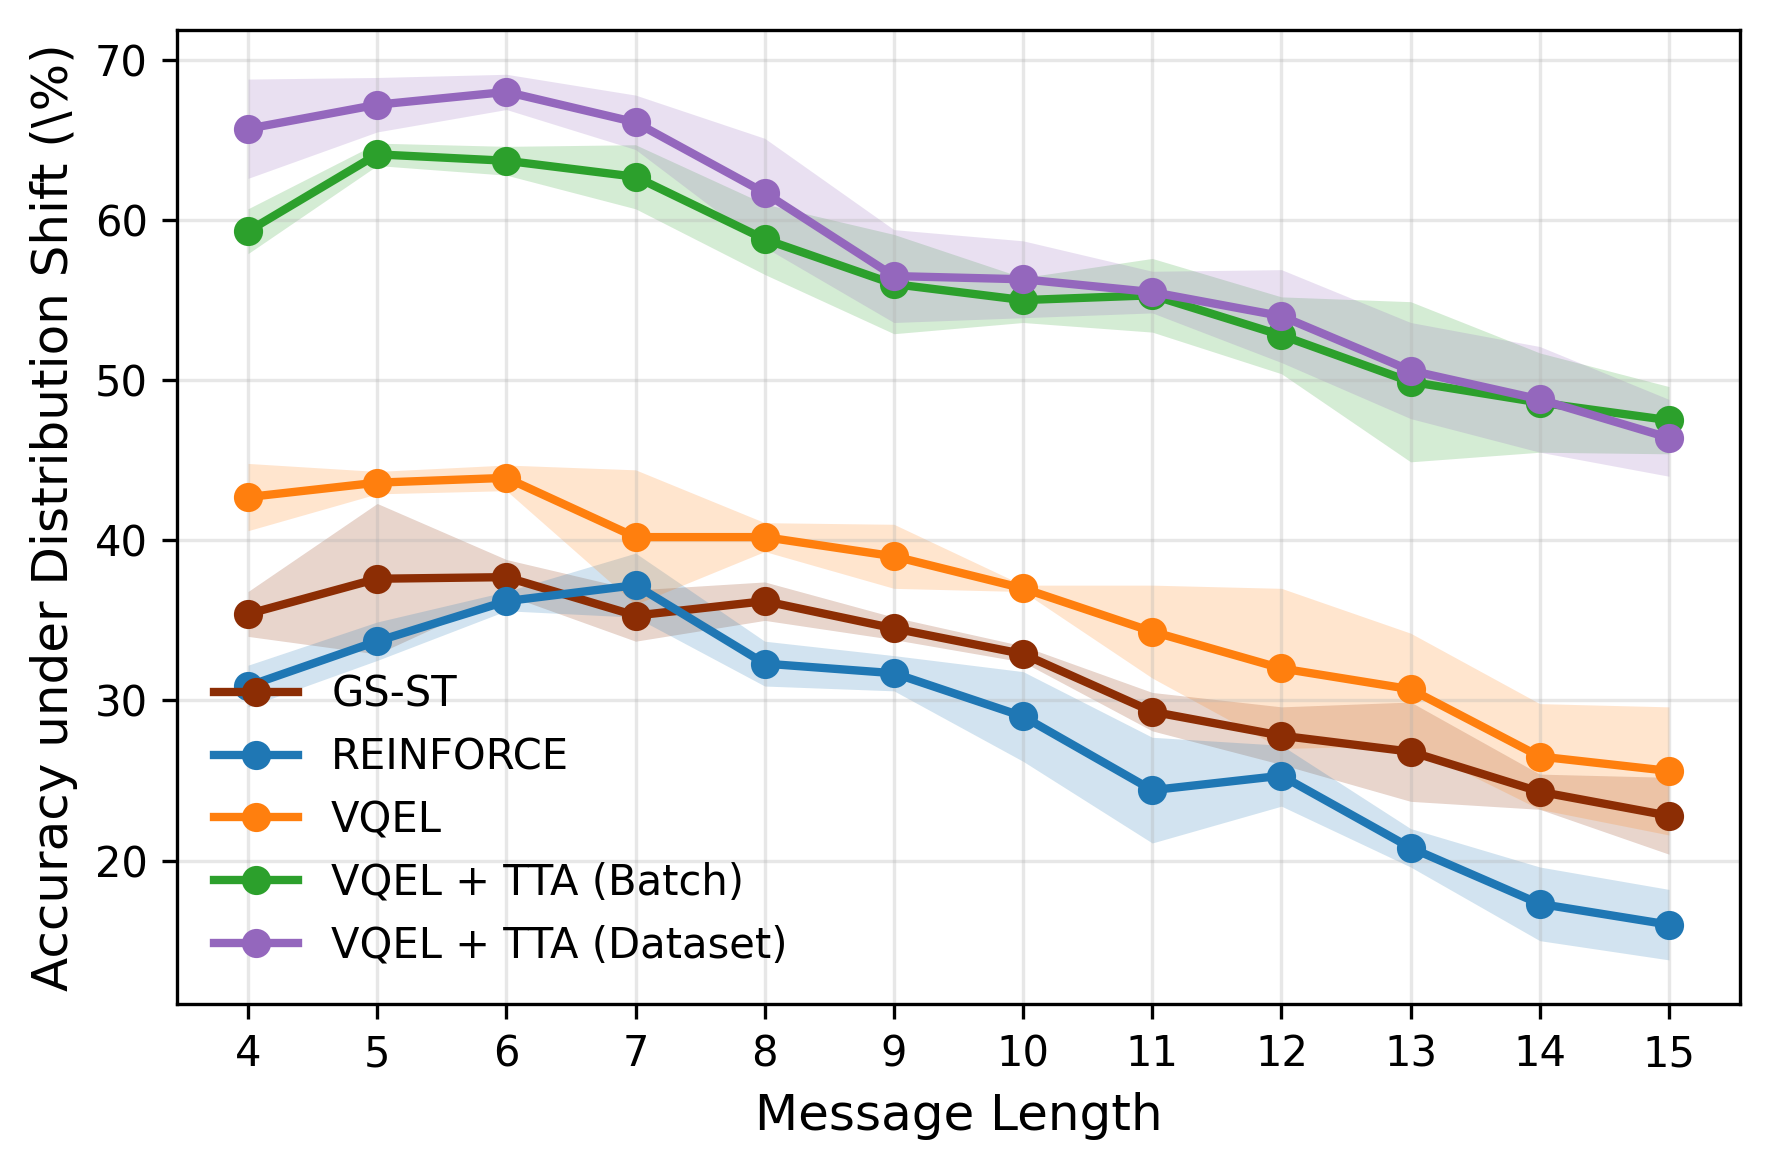

In [ ]:
# plot([gumbel, REINFORCE, VQ_NoTT, batch_adapt, dataset_adapt], name="imagenet")

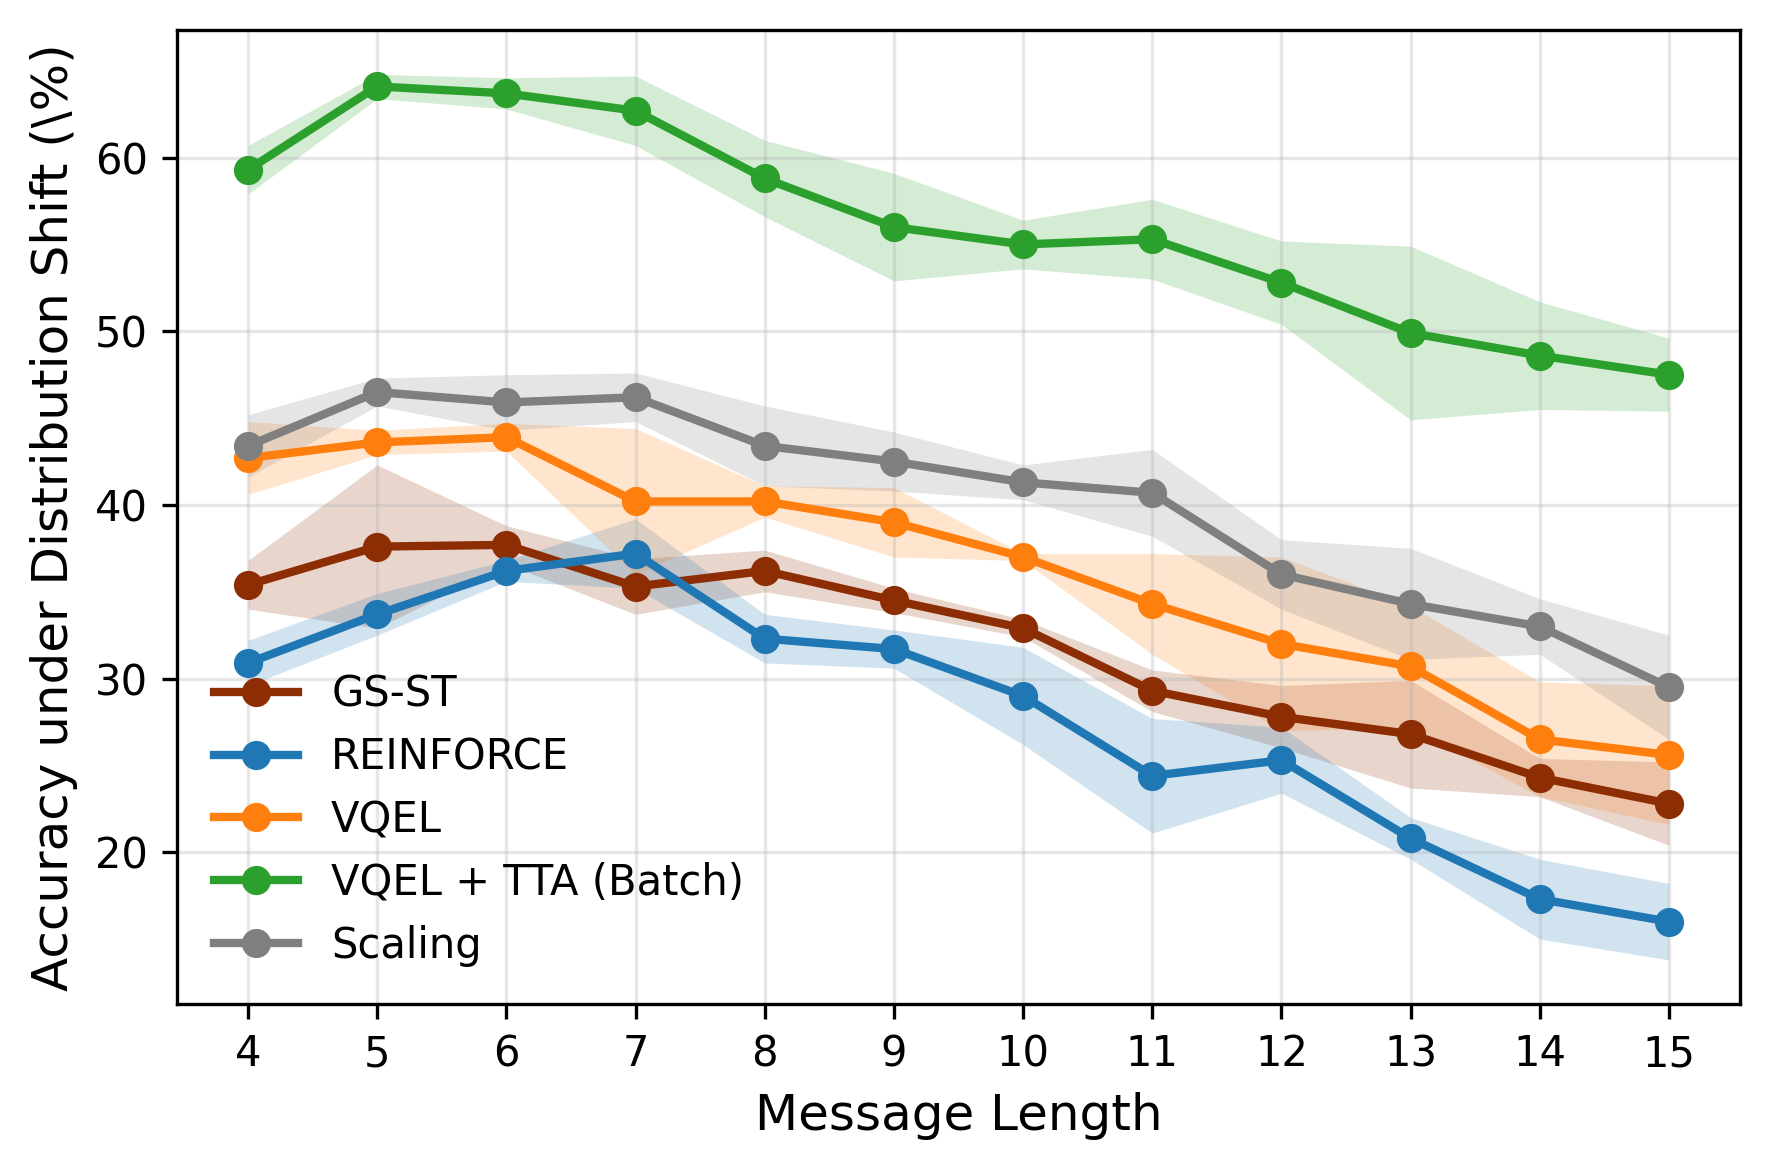

In [ ]:
# plot([gumbel, REINFORCE, VQ_NoTT, batch_adapt, scaling], labels=("GS-ST", "REINFORCE", "VQEL", "VQEL + TTA (Batch)", "Scaling"),name="imagenet-scaling")

# Batch Size

In [3243]:
adapt_cols = [
    "seed",
    "baseline",
    "dataset",
    "message_length",
    "message_length_tt",
    "dataset_tt",
    "test_time_mode",
    "number_of_candidates",
    "learning_rate_tt",
    "num_iterations",
    "test_time_self_accuracy",
    "test_time_mutual_accuracy",
    "path",
]

baseline_cols = [
    "seed",
    "baseline",
    "dataset",
    "message_length",
    "message_length_tt",
    "dataset_tt",
    "test_time_mode",
    "number_of_candidates",
    "test_time_self_accuracy",
    "test_time_mutual_accuracy",
    "path",
]

## Baseline

In [3244]:
res = filter_df({
    "dataset": "imagenet",
    "dataset_tt": "imagenet_dog_breed",
    "baseline": True,
    "test_time_mode": "-"
}, sort_by=["message_length_tt", "number_of_candidates", "seed"])

# res[baseline_cols]

In [3245]:
REINFORCE = mean_and_std(res, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "number_of_candidates"])

## VQ-NoTT

In [3246]:
res = filter_df({
    "dataset": "imagenet",
    "dataset_tt": "imagenet_dog_breed",
    "baseline": False,
    "test_time_mode": "-",
    "message_length_tt": 4
}, sort_by=["message_length_tt", "number_of_candidates", "learning_rate_tt", "num_iterations", "seed"])

# res[adapt_cols]

In [3247]:
VQ_NoTT = mean_and_std(res, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "number_of_candidates"])

## Adaptation

In [3248]:
res = filter_df({
    "dataset": "imagenet",
    "dataset_tt": "imagenet_dog_breed",
    "baseline": False,
    "test_time_mode": "dataset_adaptation"
}, sort_by=["message_length_tt", "number_of_candidates", "learning_rate_tt", "num_iterations", "seed"])

# res[adapt_cols]

In [3249]:
final = extract_maxes(res, cols=["number_of_candidates", "seed"])
# final[adapt_cols]

In [3250]:
adapt = mean_and_std(final, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "number_of_candidates"])

In [3251]:
# plot([baseline, VQ_NoTT, adapt], labels=["Baseline", "VQEL", "VQEL + TTA (Dataset)"], xlabel="Batch size", xcol="number_of_candidates")